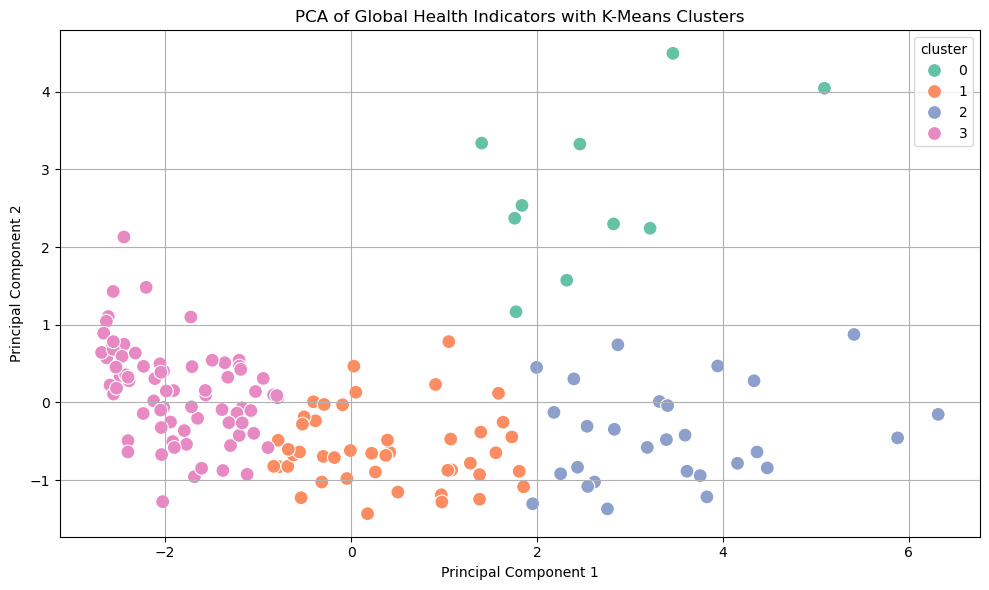


🧠 Cluster Profile Averages:


,health_exp,maternal_mortality,infant_mortality,neonatal_mortality,under_5_mortality,prev_hiv,life_expect
cluster,,,,,,,
0,10.27,324.90,40.11,24.11,52.61,12.10,60.32
1,5.04,153.11,24.43,16.16,30.03,0.94,69.09
2,4.84,491.68,50.57,27.97,73.07,2.16,60.75
3,8.47,27.64,6.81,4.64,7.96,0.32,77.21



📊 Cluster Composition by Income Group:


Income group,High income,Low income,Lower middle income,Upper middle income
cluster,,,,
0,0,4,3,3
1,1,6,20,11
2,0,14,8,1
3,40,0,8,24



📈 Normalized Income Group Distribution per Cluster:


...


📊 Cluster Composition by World Region:


Region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
cluster,,,,,,,
0,0,0,0,0,0,1,9
1,8,3,8,5,0,4,11
2,0,0,1,0,0,1,21
3,5,32,18,12,2,2,1



📈 Normalized Region Distribution per Cluster:


Region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
cluster,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,0.10,0.90
1,0.21,0.08,0.21,0.13,NaN,0.10,0.28
2,NaN,NaN,0.04,NaN,NaN,0.04,0.91
3,0.07,0.44,0.25,0.17,0.03,0.03,0.01



🌍 Sample countries in Cluster 0:
['Namibia', 'Eswatini', 'Malawi', 'Zambia', 'Lesotho']

🌍 Sample countries in Cluster 1:
['Lao PDR', 'Caribbean small states', 'Cambodia', 'Nepal', 'Timor-Leste']

🌍 Sample countries in Cluster 2:
['Africa Eastern and Southern', 'Pakistan', 'Angola', 'Sudan', 'Gambia, The']

🌍 Sample countries in Cluster 3:
['Estonia', 'Luxembourg', 'Ireland', 'United States', 'Slovenia']


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------
# Step 1: Load data and World Bank mappings
# ---------------------------------------------

# Load main dataset
df = pd.read_csv("cleaned_world_health_data.csv")

# Load mapping from Excel
mapping_df = pd.read_excel("CLASS.xlsx")
mapping_df.rename(columns={"Economy": "country"}, inplace=True)

# Merge mapping into main dataset
df = df.merge(mapping_df[["country", "Region", "Income group"]], on="country", how="left")

# Filter actual countries
df_country = df[df["entity_type"] == "country"].copy()

# Use latest year per country
df_latest = df_country.sort_values("year").groupby("country").tail(1)

# ---------------------------------------------
# Step 2: Prepare features for PCA
# ---------------------------------------------

features = [
    "health_exp", "maternal_mortality", "infant_mortality",
    "neonatal_mortality", "under_5_mortality", "prev_hiv", "life_expect"
]

df_pca = df_latest.dropna(subset=features).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[features])

# ---------------------------------------------
# Step 3: PCA and KMeans Clustering
# ---------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Store results in DataFrame
df_pca["PCA1"] = X_pca[:, 0]
df_pca["PCA2"] = X_pca[:, 1]
df_pca["cluster"] = clusters

# Add Region and Income Group
region_income_map = df_latest.set_index("country")[["Region", "Income group"]]

# Drop existing Region and Income group if already present
df_pca = df_pca.drop(columns=["Region", "Income group"], errors="ignore")

# Then join the mapping
df_pca = df_pca.join(region_income_map, on="country")

# ---------------------------------------------
# Step 4: Plot PCA Clusters
# ---------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="cluster", palette="Set2", s=100)
plt.title("PCA of Global Health Indicators with K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# Step 5: Cluster Profile Summary
# ---------------------------------------------
print("\n\U0001f9e0 Cluster Profile Averages:")
display(df_pca.groupby("cluster")[features].mean().round(2))

# ---------------------------------------------
# Step 6: Cluster Composition by Income Group
# ---------------------------------------------
print("\n\U0001f4ca Cluster Composition by Income Group:")
income_comp = df_pca.groupby(["cluster", "Income group"]).size().unstack(fill_value=0)
display(income_comp)

print("\n\U0001f4c8 Normalized Income Group Distribution per Cluster:")
display(df_pca.groupby("cluster")["Income group"].value_counts(normalize=True).unstack().round(2))

# ---------------------------------------------
# Step 7: Cluster Composition by World Region
# ---------------------------------------------
print("\n\U0001f4ca Cluster Composition by World Region:")
region_comp = df_pca.groupby(["cluster", "Region"]).size().unstack(fill_value=0)
display(region_comp)

print("\n\U0001f4c8 Normalized Region Distribution per Cluster:")
display(df_pca.groupby("cluster")["Region"].value_counts(normalize=True).unstack().round(2))

# ---------------------------------------------
# Step 8: Sample countries per cluster
# ---------------------------------------------
for c in sorted(df_pca["cluster"].unique()):
    print(f"\n\U0001f30d Sample countries in Cluster {c}:")
    print(df_pca[df_pca["cluster"] == c]["country"].sample(min(5, len(df_pca[df_pca['cluster'] == c])), random_state=42).tolist())